# caspectra — the problem, the pipeline, and the work that comes next

**A self-supervised behavioural taxonomy of cellular-automaton spacetime diagrams.**

This notebook is the *map* of the project. It is written for readers who are
comfortable with cellular automata and dynamical systems but want the
machine-learning half explained from the ground up. It is **fully runnable**:
every figure below is produced from the project's own code on a handful of
real ECA diagrams (light compute — seconds on an M4, no training).

We answer four questions, in order:

1. **What are the objects?** ECA spacetime diagrams.
2. **What is the scientific question?** Can we recover *behaviour* (the
   phenotype) without supervision — and *without* secretly recovering the
   update rule (the genotype)?
3. **How does the pipeline work, step by step?** Data → augmentation →
   self-supervised encoder → embeddings → probes + clustering → diagnostics.
4. **Where is it shaky, and what serious work comes next?** A ranked
   "sketchiness map", then a concrete heavy-compute plan with estimates.

> **The one non-negotiable constraint.** The encoder must learn *mesoscopic
> behaviour*, **not** the local update rule. A model that classifies by silently
> reconstructing the 8-bit rule table is a **failed run even at high clustering
> accuracy.** Much of the machinery below exists only to *detect* that failure.

In [1]:
# Environment & imports. MPS -> CPU; fp32; MPS fallback on (per CLAUDE.md).
import os
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")

import warnings
warnings.filterwarnings("ignore")  # keep the narrative clean; UMAP/sklearn are chatty

import numpy as np
import matplotlib.pyplot as plt
import torch

np.random.seed(0)
torch.manual_seed(0)

# First-party project code — the same modules the training/eval scripts use.
from caspectra.ca.eca import (
    ECASimulator, reflect, complement, equivalence_class, independent_rules,
)

print("torch", torch.__version__, "| MPS available:", torch.backends.mps.is_available())
print("Independent ECA equivalence classes:", len(independent_rules()))

torch 2.12.0 | MPS available: True
Independent ECA equivalence classes: 88


## 1. The objects — ECA spacetime diagrams

An **elementary cellular automaton (ECA)** is the simplest interesting dynamical
system on a lattice: a 1-D row of binary cells, updated in parallel by a local
rule that maps each cell's 3-cell neighbourhood `(left, centre, right)` to a new
value. There are $2^{2^3} = 256$ such rules (the *Wolfram rule number* is just
the 8-bit output column of the rule table).

We run each rule from a random binary initial row under **periodic boundary
conditions** and stack the rows in time, top to bottom. The result is a
square **spacetime diagram**: the horizontal axis is space, the vertical axis is
time. *This image is the only thing the rest of the pipeline ever sees.* The
rule number is hidden from the model — it is used only at evaluation time to
check what the model learned.

The diagrams below are produced by the project's `ECASimulator`. Watch how
wildly the qualitative *behaviour* varies even though the underlying machinery
(a 3-cell lookup table) is identical in form.

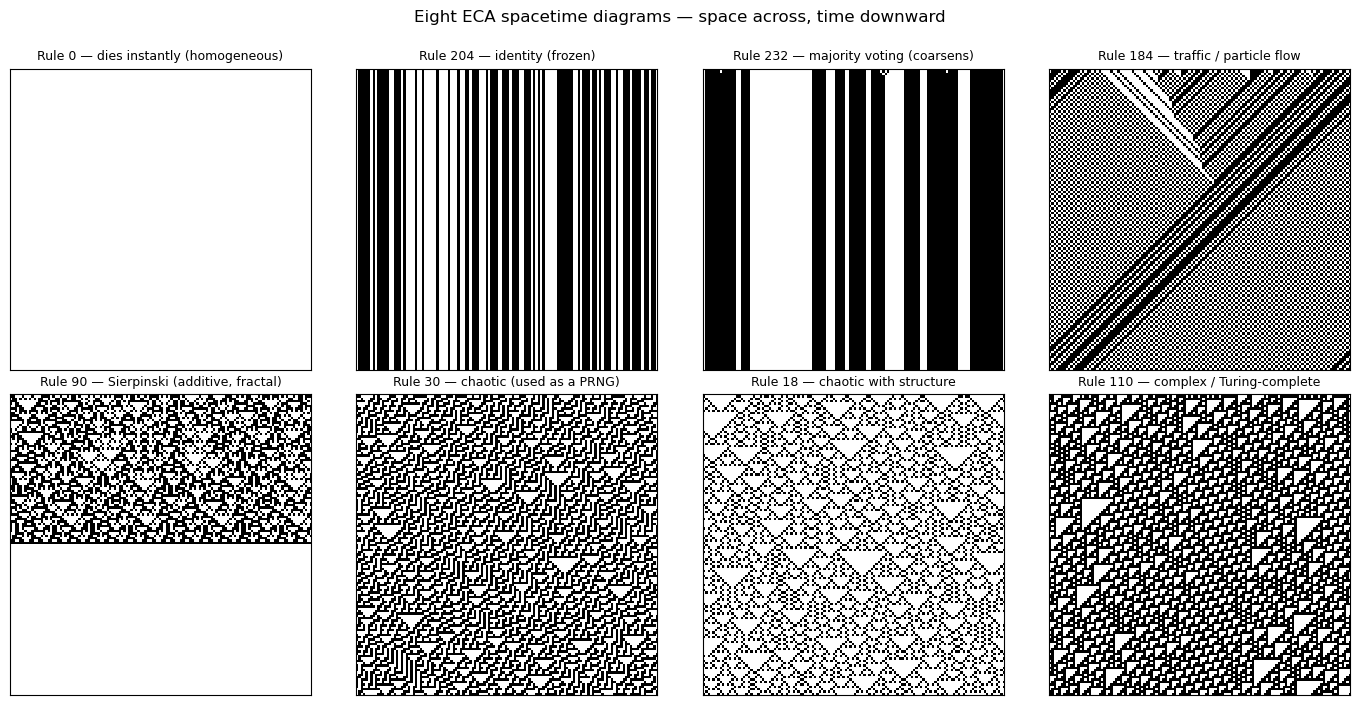

In [2]:
def diagram(rule, size=128, seed=0):
    # One spacetime diagram (size x size) from a seeded random initial row.
    rng = np.random.default_rng(seed)
    return ECASimulator(rule).random_diagram(width=size, n_steps=size, rng=rng)

# A spread across the classic qualitative behaviours.
showcase = {
    0:   "Rule 0 — dies instantly (homogeneous)",
    204: "Rule 204 — identity (frozen)",
    232: "Rule 232 — majority voting (coarsens)",
    184: "Rule 184 — traffic / particle flow",
    90:  "Rule 90 — Sierpinski (additive, fractal)",
    30:  "Rule 30 — chaotic (used as a PRNG)",
    18:  "Rule 18 — chaotic with structure",
    110: "Rule 110 — complex / Turing-complete",
}

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, (rule, title) in zip(axes.ravel(), showcase.items()):
    ax.imshow(diagram(rule), cmap="binary", interpolation="nearest")
    ax.set_title(title, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Eight ECA spacetime diagrams — space across, time downward", y=1.0)
fig.tight_layout()
plt.show()

**Read these as a physicist would.** Rule 0 and 204 are *fixed points* of the
dynamics (Wolfram class 1/2). Rule 232 *coarsens* like a voter model. Rule 184
is the canonical **traffic rule** — its diagonal stripes are conserved
"particles". Rules 90, 30, 18 are **chaotic** (class 3): 90 is exactly the
linear Sierpinski automaton, 30 is so disordered it shipped as a random-number
generator. Rule 110 is **complex** (class 4): localized "gliders" drift and
collide on a periodic background — it is Turing-complete.

The whole premise of the project is that **these qualitative differences are
visible in the texture of the image**, and that a representation learner should
be able to discover them *without being told the rule*.

## 2. The scientific question — phenotype, not genotype

Borrowing from biology (and from the prior supervised paper this project follows
up):

- **Genotype** = the *local update rule* (the 8-bit table / Wolfram number). It
  is microscopic, exact, and discrete — 256 of them.
- **Phenotype** = the *emergent mesoscopic behaviour* (homogeneous / periodic /
  chaotic / complex; particles, fronts, gliders). It is what a human sees.

We want an **unsupervised behavioural taxonomy**: cluster the diagrams by
phenotype. The validation target is the ECAs precisely because they come with
*reference* phenotype labels we can check against — the **Li–Packard (5
classes)** and **Wolfram (4 classes)** taxonomies.

### Two symmetries: 256 rules collapse to 88

Two rules are "the same automaton" if related by **left↔right reflection** or
**0↔1 complementation**. The project computes these equivalence classes
programmatically and trains on one representative per class — so behaviour is
never double-counted.

In [3]:
# The symmetry group is generated by reflect & complement (each an involution).
r = 90
print(f"rule {r}: reflect -> {reflect(r)}, complement -> {complement(r)}")
print(f"equivalence class of {r}: {sorted(equivalence_class(r))}")
print(f"equivalence class of 110: {sorted(equivalence_class(110))}")
print(f"equivalence class of 0:   {sorted(equivalence_class(0))}  (a singleton)")
print()
print(f"256 rules  ->  {len(independent_rules())} independent equivalence classes")

rule 90: reflect -> 90, complement -> 165
equivalence class of 90: [90, 165]
equivalence class of 110: [110, 124, 137, 193]
equivalence class of 0:   [0, 255]  (a singleton)

256 rules  ->  88 independent equivalence classes


> **Sketchiness flag #1 — the reference labels are not ground truth.** Li–Packard
> and Wolfram classes are *human, partly subjective* judgements, the boundaries
> (especially class 3 vs 4) are genuinely fuzzy, and the classes are *severely
> imbalanced* (complex/class-4 rules are rare). We therefore treat agreement with
> them as **evidence**, never as accuracy against truth — and we report
> *balanced* accuracy and macro-F1, not just raw accuracy.

## 3. Why this is hard — the rule-reconstruction cheat

Here is the trap. A sufficiently powerful CNN can classify the diagrams almost
perfectly by **reverse-engineering the rule table** from a few local
patches — and a model that has memorized the genotype will *also* cluster
neatly, score high on any behavioural metric, and look like a triumph. It would
be a complete scientific failure: it learned the thing we explicitly do not want.

The prior supervised paper made this concrete with the **"T-tetromino"**: a
convolutional kernel that can see a full 3-cell neighbourhood *together with the
output cell it produced one row below* has literally observed one row of the
rule's truth table. Enough such observations reconstruct the genotype.

Two design principles fall out of this, and the project bakes both into the
default encoder (`AntiCheatCNN`):

1. **No first-layer kernel may span a T-tetromino.** A `2×2` first kernel sees
   only two of the three input cells at once, so it *cannot* read a rule-table
   entry directly.
2. **The representation must pass through a small bottleneck** (default 64-d),
   too small to comfortably store the 8-bit rule for all classes.

The genotype/phenotype distinction, and these two anti-cheating principles, are
the conceptual core of the project — see `SELF_CRITICISM.md` for the full
argument and its limits.

## 4. The pipeline at a glance

```
   ECA rules ──► spacetime diagrams ──► TWO augmented views per diagram
   (genotype)        (the images)         (cyclic-shift, coarse-grain)
                                                   │
                                                   ▼
                                   self-supervised encoder  (BYOL / SimSiam)
                                   learns: "two views of the SAME diagram
                                            → nearby embeddings"
                                                   │
                                                   ▼
                                   frozen encoder ──► embedding per diagram
                                                   │
                        ┌──────────────────────────┼───────────────────────────┐
                        ▼                           ▼                           ▼
                 LINEAR PROBES              UMAP + HDBSCAN               DIAGNOSTICS
            rule? LP class? Wolfram?    unsupervised clusters       the gap, conditional
            (the GAP = LP − rule)      (ARI / NMI / purity)         MI, collapse-std,
                                                                    hand-crafted baseline
```

The three downstream blocks answer three different questions:
**probes** — *is the behaviour linearly decodable (and is the rule suppressed)?*
**clustering** — *does a taxonomy emerge with no labels at all?*
**diagnostics** — *did we cheat?*

The next four sections walk each stage with runnable code.

## 5. Augmentations — the scientifically load-bearing choice

In self-supervised learning, *you never tell the model what to predict*. The
**only** signal is: "these two views are the same object; pull their embeddings
together." So **the augmentations literally define what 'the same' means** — and
therefore what invariances the encoder is forced to learn. For natural images
people use colour jitter and crops; for CA diagrams those would be nonsense or
actively harmful. The project uses exactly two default augmentations, each
chosen on physical grounds:

- **Cyclic shift** — roll the image horizontally. Under periodic boundaries this
  is an *exact symmetry*: no information is destroyed, it only says "absolute
  spatial phase is irrelevant." Safe and free.
- **Coarse-grain** — average-pool 2×2 then upsample back. This *deliberately
  destroys microscopic / rule-level detail while preserving mesoscopic
  structure.* It is the key **genotype-suppressing** augmentation: if two views
  must map together even after one is blurred, the encoder cannot rely on
  pixel-exact rule signatures.

Deliberately **excluded**: time/vertical flips (time is irreversible for a CA),
rotations/transposes (they mix the physically distinct space and time axes), and
salt-and-pepper noise. These are documented as off-by-design in
`data/augmentations.py`.

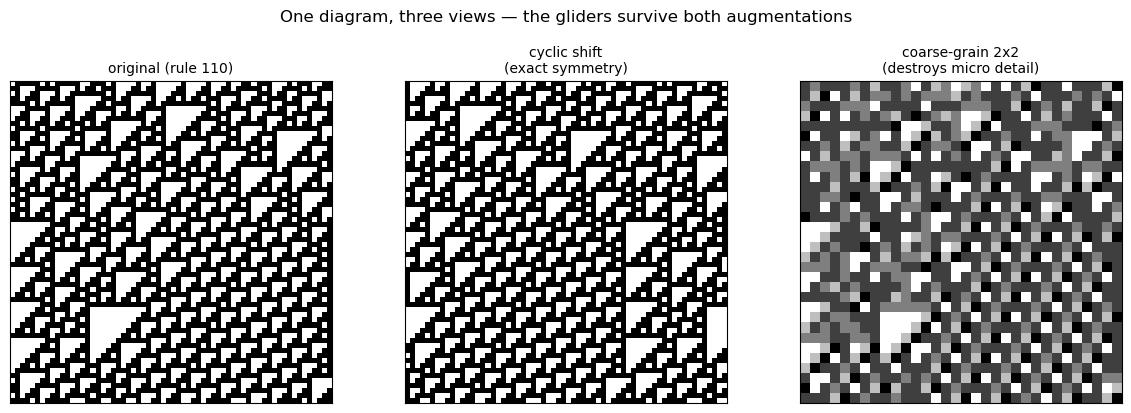

In [4]:
from caspectra.data.augmentations import CyclicShift, CoarseGrain, TwoViewTransform, AugmentationConfig

img = torch.from_numpy(diagram(110, size=64)).float().unsqueeze(0)  # (1, H, W)

shifted = CyclicShift()(img)
coarse  = CoarseGrain(kernel=2, p=1.0)(img)   # p=1 here to force the effect for display

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, x, t in zip(
    axes,
    [img, shifted, coarse],
    ["original (rule 110)", "cyclic shift\n(exact symmetry)", "coarse-grain 2x2\n(destroys micro detail)"],
):
    ax.imshow(x.squeeze(0).numpy(), cmap="binary", interpolation="nearest")
    ax.set_title(t, fontsize=10); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("One diagram, three views — the gliders survive both augmentations", y=1.02)
fig.tight_layout(); plt.show()

> **Sketchiness flag #2 — coarse-graining is a hypothesis, not a proof.** We
> *assume* 2×2 averaging removes genotype while keeping phenotype. But a crop or
> blur of a CA diagram still contains many full rule-table instances, so the
> suppression is partial and empirical, not guaranteed. To reduce a train/eval
> mismatch (training on blurred views, evaluating on raw diagrams) the project
> applies coarse-grain **stochastically** (`coarse_grain_prob=0.5`), so the
> encoder also sees fine detail. Whether this is the right knob is an open
> empirical question — it is exactly the kind of thing the diagnostics in §7
> are meant to adjudicate.

## 6. The self-supervised encoder (BYOL / SimSiam)

**The idea, for a dynamical-systems audience.** We want a function
$f_\theta:\text{image}\to\mathbb{R}^d$ such that *behaviourally similar diagrams
land near each other*, learned with **no labels**. The trick: build two
augmented views of each diagram, push both through the encoder, and train so the
two embeddings agree. The danger is the trivial solution — map *everything* to
one constant point ("collapse"), which makes views agree perfectly while
learning nothing.

- **BYOL** (default) avoids collapse with an asymmetry: an *online* network is
  trained to predict the output of a slowly-updated *target* network (an
  exponential moving average of itself), with a stop-gradient on the target.
  There are no negative pairs. Works best at batch ≳ 256.
- **SimSiam** is the lighter cousin — same stop-gradient + predictor trick, *no*
  target network, so it is small-batch-native and the default for M4 smoke runs.

Both wrap one of the project's encoders and expose the same surface:
`forward(view_a, view_b) -> loss` and `extract_embedding(x)`. Below we
instantiate the **anti-cheat encoder** (2×2 kernels + 64-d signed bottleneck,
§3) inside SimSiam and run one forward pass.

In [5]:
from caspectra.models.encoder import AntiCheatCNN
from caspectra.models.byol import BYOL, SimSiam

encoder = AntiCheatCNN(embedding_dim=64)               # 2x2 kernels, small signed bottleneck
n_params = sum(p.numel() for p in encoder.parameters())
print(f"AntiCheatCNN: embedding_dim={encoder.embedding_dim}, params={n_params:,}")

model = SimSiam(encoder, projection_hidden=2048, projection_out=2048, prediction_hidden=512)

# A tiny batch of positive pairs straight from the augmentation pipeline.
two_view = TwoViewTransform(AugmentationConfig())
batch = torch.stack(
    [torch.from_numpy(diagram(r, size=64)).float() for r in [0, 90, 110, 30]]
).unsqueeze(1)  # (4,1,64,64)
view_a = torch.stack([two_view(b)[0] for b in batch])
view_b = torch.stack([two_view(b)[1] for b in batch])

loss = model(view_a, view_b)
emb = model.extract_embedding(batch)
print(f"one SimSiam loss on a 4-pair batch: {loss.item():.4f}   (negative cosine sim; ~ -1 is best)")
print(f"embedding shape: {tuple(emb.shape)}  (one 64-d vector per diagram)")

AntiCheatCNN: embedding_dim=64, params=31,264
one SimSiam loss on a 4-pair batch: -0.0026   (negative cosine sim; ~ -1 is best)
embedding shape: (4, 64)  (one 64-d vector per diagram)


> **This encoder is randomly initialised** — the embeddings above are *not*
> meaningful yet. Producing a useful $f_\theta$ requires actually **training**
> over the full dataset for many epochs, which is the heavy step deferred to §8.
> Everything downstream (§7) is shown on a transparent stand-in so the machinery
> is concrete without waiting on a training run.
>
> **Sketchiness flag #3 — SSL on CA diagrams is unproven and collapse is silent.**
> BYOL/SimSiam were designed for natural-image statistics; CA diagrams are
> binary, highly structured, and (for class 1/2 rules) nearly constant.
> Collapse minimises the loss just as well as real learning, so a falling loss
> curve is *not* evidence of success — which is why the trainer logs an
> `embedding_std` collapse metric every epoch.

## 7. Evaluation — probes, clustering, and the cheat-detectors

This is where the project earns or loses its scientific keep. To make every
piece *runnable now*, we evaluate a transparent stand-in for the (not-yet-trained)
encoder: the project's **hand-crafted, label-free baseline features**
(`mean_density`, `temporal_activity`, `compression_ratio`, `block_entropy`).

This is not a throwaway — it is itself one of the diagnostics: **a deep
embedding must beat these cheap descriptors, or it isn't earning its keep.** A
real run drops a trained 64-d embedding into the exact same calls.

First, a small real dataset over eight rules with known reference classes.

In [6]:
from caspectra.eval.labels import RuleLabels
from caspectra.eval.baselines import FEATURE_NAMES, compute_baseline_features

# Build a small real dataset: 8 rules x 40 random initial conditions, 64px.
DEMO_RULES = [0, 204, 232, 184, 90, 30, 18, 110]
N_IC = 40
SIZE = 64

rng = np.random.default_rng(0)
images, rules = [], []
for rule in DEMO_RULES:
    sim = ECASimulator(rule)
    for _ in range(N_IC):
        ic = rng.integers(0, 2, size=SIZE, dtype=np.uint8)
        images.append(sim.evolve(ic, SIZE))
        rules.append(rule)
images = np.stack(images)
rules = np.array(rules)

# Illustrative reference labels (literature values for these 8 rules ONLY).
# The canonical, complete table lives in rule_labels.csv; this is a demo stand-in.
lp = {0:1, 204:2, 232:2, 184:3, 90:5, 30:5, 18:5, 110:4}        # Li-Packard (5 classes)
wolf = {0:1, 204:2, 232:2, 184:2, 90:3, 30:3, 18:3, 110:4}       # Wolfram (4 classes)
labels = RuleLabels(lp=lp, wolfram=wolf)

# The "embedding": label-free baseline descriptors (a trained encoder replaces this).
features = compute_baseline_features(images)
print("dataset:", images.shape, "| feature matrix:", features.shape)
print("features:", FEATURE_NAMES)

dataset: (320, 64, 64) | feature matrix: (320, 4)
features: ['mean_density', 'temporal_activity', 'compression_ratio', 'block_entropy']


### 7a. Linear probes and *the gap* (the headline metric)

Freeze the representation, fit a logistic-regression probe from embedding →
label, and read the held-out accuracy. Three probes matter:

- **embedding → rule identity**: we want this **well below 100%**. Near-perfect
  means the genotype leaked in.
- **embedding → LP / Wolfram class**: we want this **well above** the
  majority-class baseline.

The single headline number — straight from the prior supervised paper — is the

$$\textbf{gap} = \text{acc}(\text{behaviour class}) - \text{acc}(\text{exact rule})$$

A **large positive gap** is the signature of success: behaviour is decodable
*while* the exact rule is suppressed.

In [7]:
from caspectra.eval.probes import run_probes

report = run_probes(features, rules, labels, seed=0)
print(report.summary())

Linear probes (rule identity should be WELL BELOW 1.0):
    rule: acc=0.948 bal_acc=0.948 macroF1=0.947 baseline=0.125 (8 classes)
      lp: acc=1.000 bal_acc=1.000 macroF1=1.000 baseline=0.375 (5 classes)
 wolfram: acc=0.990 bal_acc=0.979 macroF1=0.986 baseline=0.375 (4 classes)
    gap = LP_acc − rule_acc = +0.052 (want large & positive: behaviour learned, rule suppressed)


Interpretation (on this baseline stand-in): the LP/Wolfram probes are near
perfect (these eight rules are behaviourally very distinct), but notice the rule
probe is **also** high (~0.95) — four scalar texture statistics are already
enough to nearly *identify the rule* among these eight. So the **gap is small
(~+0.05)**. That is precisely the cautionary lesson: cheap features can be
surprisingly rule-revealing, and a small gap is a *weak* result. **The trained
encoder's real job is to push the rule probe down** (suppress the genotype) while
keeping LP high — widening the gap toward the supervised reference of roughly
LP ≈ 98% with rule ≈ 61% (gap ≈ +0.37). The metric, not this particular number,
is the point.

In [8]:
# Leave-rules-out: hold out WHOLE rules to test transfer to unseen rules of a
# known class. (Here each LP class has few rules, so this is illustrative only.)
report_lro = run_probes(features, rules, labels, seed=0, lp_split="rules")
print("Leave-rules-out (transfer to unseen rules):")
print(f"  LP probe accuracy: {report_lro.lp.accuracy:.3f}"
      if report_lro.lp else "  (no LP labels)")

Leave-rules-out (transfer to unseen rules):
  LP probe accuracy: 0.667


### 7b. Unsupervised clustering — does a taxonomy *emerge*?

The probes are supervised (they peek at labels). The clustering does not: we
L2-normalise the embeddings, project with **UMAP** (cosine metric), and let
**HDBSCAN** decide *how many* clusters there are (points it can't assign become
"noise", label −1). We then score the discovered clusters against the reference
classes with **ARI / NMI / purity**.

In [9]:
from caspectra.eval.cluster import cluster_pipeline, cluster_count_stability

creport = cluster_pipeline(
    features,
    umap_components=5, umap_metric="cosine",
    min_cluster_size=15, min_samples=5, seed=0,
    rules=rules, labels=labels,
)
print(creport.summary())

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Discovered clusters: 10 (noise points: 0); reference: 5 LP, 4 Wolfram
vs LP:      ARI=0.531 NMI=0.797 purity=1.000
vs Wolfram: ARI=0.418 NMI=0.716 purity=1.000
Genotype leakage: excess rule info MI(cluster;rule|LP)=0.424 nats (want ~0; large = leakage). [MI rule=1.918, LP=1.494]


### 7c. The cheat-detectors

Two diagnostics specifically hunt the failure mode:

- **Excess rule information** $\;\text{MI}(\text{cluster};\text{rule}\mid\text{LP})
  = \text{MI}(\text{cluster};\text{rule}) - \text{MI}(\text{cluster};\text{LP})$.
  Because the LP class is a deterministic function of the rule, this is $\ge 0$
  by the data-processing inequality, and we want it **near zero**: the clusters
  should carry *no* information about the exact rule beyond what the coarse
  behavioural class already implies. (This replaces an earlier framing — "want
  MI(cluster;rule) low and MI(cluster;LP) high" — which is *mathematically
  impossible* to satisfy, since the former can never be below the latter.)
- **Cluster-count stability** — the "number of discovered clusters" is **not** an
  emergent constant; it depends on HDBSCAN's `min_cluster_size`. Reporting the
  sweep is more honest than headlining one number.

In [10]:
print(f"excess rule info  MI(cluster; rule | LP) = {creport.mi_rule_given_lp:.3f} nats "
      f"(want ~0)   [MI rule={creport.mi_rule:.3f}, MI LP={creport.mi_lp:.3f}]")

sweep = cluster_count_stability(
    features, [5, 10, 15, 20, 30],
    umap_components=5, umap_metric="cosine", min_samples=5, seed=0,
)
print("cluster-count stability (min_cluster_size -> n_clusters):", sweep)

excess rule info  MI(cluster; rule | LP) = 0.424 nats (want ~0)   [MI rule=1.918, MI LP=1.494]


cluster-count stability (min_cluster_size -> n_clusters): [(5, 15), (10, 12), (15, 10), (20, 9), (30, 7)]


Read the baseline's verdict honestly: it **over-segments** (≈10 clusters where
there are 4–5 reference classes, and the count slides from 15 down to 7 across
the sweep — *not* a stable emergent number), and it carries **non-trivial excess
rule information** (~0.4 nats — the clusters know more about the exact rule than
the behavioural class alone implies). In other words, the cheap baseline is
*decent but leaky and unstable.* This is exactly the "not yet good enough"
picture a trained, genotype-suppressed encoder must improve on: fewer, stabler
clusters that align with behaviour, with excess rule information driven toward
zero.

> **Sketchiness flag #4 — UMAP+HDBSCAN is a researcher-degrees-of-freedom
> minefield.** `n_neighbors`, `umap_components`, `min_cluster_size`,
> `min_samples`, the metric — all change the answer, and it is easy to tune them
> until the clusters "look right" against the very labels we claim not to use.
> The stability sweep above is a partial guard, but the honest move is to
> **pre-register** these hyperparameters before looking at agreement scores.

## 8. The sketchiness map — where this could go wrong, ranked

Pulling the inline flags together, roughly in order of *how much they threaten
the conclusion* (full treatment in `SELF_CRITICISM.md`):

| # | Risk | Why it bites | Current mitigation |
|---|------|--------------|--------------------|
| 1 | **The genotype cheat** | High clustering accuracy can be the *failure* mode, not success | Anti-cheat encoder (2×2 kernels, 64-d bottleneck) + rule probe + excess-MI + the gap |
| 2 | **Coarse-grain assumption** | "blur removes genotype, keeps phenotype" is unproven and partial | stochastic coarse-grain; hand-crafted baseline as a floor |
| 3 | **SSL may not work here / silent collapse** | BYOL/SimSiam are tuned for natural images; CA diagrams are binary & often near-constant | `embedding_std` collapse metric logged every epoch; SimSiam fallback |
| 4 | **Reference labels aren't truth** | LP/Wolfram are subjective, fuzzy (class 3 vs 4), and imbalanced | balanced-acc + macro-F1; treat agreement as *evidence* |
| 5 | **Clustering researcher-DoF** | UMAP/HDBSCAN knobs can be tuned to flatter the labels | cluster-count stability sweep; pre-register knobs (TODO) |
| 6 | **Does the deep model beat trivial features?** | a 4-number baseline may match the embedding | baseline probes/clustering run in the same harness |
| 7 | **Generalisation beyond ECAs** | the real goal is open-ended CA taxonomy; ECAs are a toy validation set | `nuca.py` interface stub; out of current scope |

None of these is fatal *if measured*. The project's stance is: **build the
detectors first, then believe the taxonomy only if it survives them.**

## 9. The serious work that comes next

Everything above ran in seconds because it skipped the one expensive thing:
**actually training the encoder.** That is the next real step.

### 9.1 The heavy computation

Train the self-supervised encoder on the **full ECA validation set**:

| Quantity | Value | Note |
|---|---|---|
| Rules | **88** | one representative per equivalence class |
| Initial conditions / rule | **256** | → **22 528** diagrams |
| Grid size | **128 × 128** | 64 is smoke-only |
| Dataset tensor | ≈ **0.37 GB** uint8 | fits in memory; cached to `.npz` once |
| Method | **BYOL** (→ SimSiam if batch < ~256) | GroupNorm at small batch |
| Encoder | **AntiCheatCNN** (default) or ResNet18 ablation | anti-cheat is the scientific default |
| Epochs / batch | **100 / 128** | per `configs/default.yaml` |
| Optimiser | AdamW, lr 1e-3, EMA τ 0.996 | |

**Rough M4 wall-clock (order of magnitude, MPS, fp32 — verify by timing one
epoch first):**

- Dataset generation: **a few minutes**, then cached (free thereafter).
- `AntiCheatCNN` (~0.1–0.5 M params): a few seconds/epoch → **well under an hour** for 100 epochs.
- `ResNet18` + BYOL (target branch doubles compute): on the order of **2–4 hours** for 100 epochs.
- Evaluation (embeddings + probes + UMAP/HDBSCAN): **minutes.**

### 9.2 How to execute it well

1. **Provide `rule_labels.csv`** (the Li–Packard / Wolfram table) at the repo
   root — this unlocks the LP/Wolfram probes, the gap, the contingency tables,
   and the excess-MI diagnostic. Without it, only the rule probe and bare
   clustering run.
2. **Smoke first, always.** `python scripts/train.py --config configs/smoke.yaml`
   then `evaluate.py` — 6 rules / 64px / 3 epochs catches integration bugs in
   ~a minute. (Project rule: never launch a 128px run before the smoke passes.)
3. **Time one real epoch** at 128px before committing to 100 — confirm the
   estimate and the batch size that fits M4 memory (drop to SimSiam if BYOL
   forces batch < ~256).
4. **Pre-register** the success thresholds and the UMAP/HDBSCAN knobs *before*
   looking at LP/Wolfram agreement (mitigates risks #4–#5 above).
5. **Run the encoder ablation** (`anticheat` vs `resnet18`): the gap between them
   is itself a measurement of how much rule-reconstruction the architecture
   permits.
6. Launch the full run **only after explicit sign-off** (per `CLAUDE.md`), with
   `PYTORCH_ENABLE_MPS_FALLBACK=1` set.

```bash
export PYTORCH_ENABLE_MPS_FALLBACK=1
python scripts/generate_data.py --config configs/default.yaml   # cache once
python scripts/train.py    --config configs/smoke.yaml          # smoke
python scripts/evaluate.py --config configs/smoke.yaml
# ... inspect, time one full epoch, then:
python scripts/train.py    --config configs/default.yaml        # the real run
python scripts/evaluate.py --config configs/default.yaml
```

### 9.3 What we expect to see (hypotheses, to be pre-registered)

A **successful** run should show, *together*:

- **Rule probe well below 100%** (target: clearly sub-ceiling, ~50–75%) — the
  genotype is suppressed.
- **LP/Wolfram probe well above the majority baseline**, giving a **large
  positive gap** (aspiration: approach the supervised gap of ≈ +0.37 *without*
  supervision).
- **Excess rule info ≈ 0** and a **stable** discovered-cluster count in the
  neighbourhood of the 4–5 reference classes across the `min_cluster_size` sweep.
- **The embedding beats the hand-crafted baseline** on the gap — otherwise the
  deep pipeline isn't justified.
- **`embedding_std` stays well above 0** throughout training — no collapse.

A **failure / cheat** looks like: rule probe near 100%, large positive
excess-MI, clusters that track individual rules rather than behaviour classes —
*even if* ARI against LP looks superficially high. The point of §7 is to make
that distinction unambiguous **before** we believe any taxonomy.